# 指数法 vs 面积法 交叉验证 (Index vs Area cross-check)

在**同一批冻结的 654 颗 XGB threshold 候选星**上，比较两条解耦的 CN 增强筛选方法（指数法 `cn_index_screening` / 面积法 `cn_area_screening`）的结果：各档位各自标记多少候选 / 已知 CN 星、两法重叠度（Jaccard）、其 z 分数一致性（Pearson / Spearman），以及 shared / index-only / area-only 三组在光谱残差上的差异。所有重活（输入校验、缓存、参考池、指数表与面积表）都委托给 `cn_common`，本笔记本只做分组与交叉统计量。

## 1. 环境与输入边界

解释器固定为 `myenv`。候选成员唯一权威来源为 `XGB/XGB_PU_candidates_threshold.csv`（654 行）；已知 CN 星由缓存中 `label == 1` 标记（91 颗），参考池构造时被排除。任一 UID 一致性失败都会停止。

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'feature' else NOTEBOOK_DIR
for p in (str(NOTEBOOK_DIR), str(PROJECT_ROOT)):
    if p not in sys.path:
        sys.path.insert(0, p)

import cn_common as cc
import cn_method_crosscheck as cx

print('python:', sys.executable)
print('notebook dir:', NOTEBOOK_DIR)
print('crosscheck dir:', cx.RESULTS_CROSSCHECK_DIR)

python: D:\Anaconda\envs\myenv\python.exe
notebook dir: D:\资料\2026大创\Lamost\feature
crosscheck dir: D:\资料\2026大创\Lamost\feature\results_crosscheck


## 2. 加载两法完整表 + 复现性自检

`load_method_tables` 重建指数法与面积法的完整 654 行表，并**强制复现性自检**：重建出的 `grade_1p0` 为 True 的 uid 集合必须与已冻结导出文件 `results_index/cn_index_candidates.csv`（159）和`results_area/cn_area_candidates.csv`（147）的 uid 集合**完全一致**，否则 `assert` 报错。

In [2]:
t = cx.load_method_tables(repro_check=True, tier='1p0')
index_cand = t['index_cand']; index_known = t['index_known']
area_cand  = t['area_cand'];  area_known  = t['area_known']
ctx = t['ctx']
print('reproducibility self-check: PASSED (rebuilt 1sigma uid sets == frozen exports)')
print('candidate universe:', len(index_cand))
print('known universe    :', len(index_known))
assert len(index_cand) == 654 and len(area_cand) == 654
assert len(index_known) == 91 and len(area_known) == 91

从 dr13_all_cache 加载:
  X_clean:      (41243, 700)
  stars_clean:  41,243 行
  feature_df:   (41243, 20)
  已知 CN 星:   91


  targets: candidates=654, known CN=91, normal refs=30128


  leave-one-out normal area: 2000/30128


  leave-one-out normal area: 4000/30128


  leave-one-out normal area: 6000/30128


...

  leave-one-out normal area: 24000/30128


  leave-one-out normal area: 26000/30128


  leave-one-out normal area: 28000/30128


  leave-one-out normal area: 30000/30128


reproducibility self-check: PASSED (rebuilt 1sigma uid sets == frozen exports)
candidate universe: 654
known universe    : 91


## 3. 分组标记 (group_labels)

在 1σ 档位下，把每颗候选星分入 `both` / `index-only` / `area-only` / `neither` 四组，得到长度 = 654 全宇宙的 uid→group 映射。

In [3]:
labels = cx.group_labels(index_cand, area_cand, tier='1p0')
print('group value counts (tier=1p0):')
print(labels.value_counts())
assert set(labels.unique()) <= {'both', 'index-only', 'area-only', 'neither'}
assert len(labels) == 654

group value counts (tier=1p0):
group_1p0
neither       483
both          135
index-only     24
area-only      12
Name: count, dtype: int64


## 4. 各档位重叠汇总 (build_overlap_summary)

对 1.0/1.5/2.0/2.5σ 四档分别给出：两法候选数、both / index-only / area-only / 并集 Jaccard，以及已知 91 颗星的 both / index-only / area-only / neither 与两法各自的召回率。

In [4]:
summary_df = cx.build_overlap_summary(index_cand, area_cand, index_known, area_known)
display(summary_df)

,tier,n_index,n_area,both,index_only,area_only,jaccard,known_both,known_index_only,known_area_only,known_neither,known_recall_index,known_recall_area
0,1p0,159,147,135,24,12,0.789474,32,6,2,51,0.417582,0.373626
1,1p5,83,79,70,13,9,0.760870,17,5,0,69,0.241758,0.186813
2,2p0,28,25,20,8,5,0.606061,9,4,1,77,0.142857,0.109890
3,2p5,10,12,9,1,3,0.692308,7,0,0,84,0.076923,0.076923


## 5. z 分数一致性 (plot_z_consistency)

对 CN3839 / CN4142 两带，比较指数法 z（std 带）与面积法 z（area 带）的相关强度：Pearson 衡量线性一致，Spearman 衡量单调秩一致，按三组着色。PNG 由第 8 步 `export_outputs` 统一写出。

In [5]:
for band in ('cn3839', 'cn4142'):
    _, (pr, sr) = cx.plot_z_consistency(index_cand, area_cand, band, labels=labels)
    print(f'{band}: Pearson={pr:.3f}, Spearman={sr:.3f}')

cn3839: Pearson=0.972, Spearman=0.972


cn4142: Pearson=0.972, Spearman=0.973


## 6. 三组光谱残差剖面 (group_residual_profiles)

把 shared / index-only / area-only 三组各自的候选光谱减去其匹配的正常参考谱，取中位残差曲线；并报告 CN3839 / CN4142 / CH4300 三个波段窗口内的平均 Δflux，看三组在分子带增强上的差异。

In [6]:
bm = cx.group_residual_band_means(ctx, index_cand, area_cand, tier='1p0')
display(bm)

,group,n,cn3839,cn4142,ch4300
0,both,135,-0.085075,-0.006017,0.006918
1,index-only,24,-0.063172,-0.002854,0.010253
2,area-only,12,-0.056145,-0.005173,-0.000949


## 7. 导出全部交叉验证产物 (export_outputs)

一次性写出 `results_crosscheck/`：654 行分组表 `crosscheck_groups.csv`、三组 Top30 光谱图（`shared_top30.png` / `index_only_top30.png` / `area_only_top30.png`）、`group_residual_profiles.png`、`z_consistency_cn3839.png` / `z_consistency_cn4142.png`、`overlap_by_tier.png`、`crosscheck_summary.json`。

In [7]:
paths = cx.export_outputs(t, summary_df, out_dir=cx.RESULTS_CROSSCHECK_DIR, tier='1p0')
print('written files:')
for k, v in paths.items():
    if k != 'z_consistency_png':
        print(' ', k, '->', v)
print(' z_consistency_png ->', paths['z_consistency_png'])

written files:
  groups_csv -> D:\资料\2026大创\Lamost\feature\results_crosscheck\crosscheck_groups.csv
  shared_top30 -> D:\资料\2026大创\Lamost\feature\results_crosscheck\shared_top30.png
  index_only_top30 -> D:\资料\2026大创\Lamost\feature\results_crosscheck\index_only_top30.png
  area_only_top30 -> D:\资料\2026大创\Lamost\feature\results_crosscheck\area_only_top30.png
  residual_profiles -> D:\资料\2026大创\Lamost\feature\results_crosscheck\group_residual_profiles.png
  summary_json -> D:\资料\2026大创\Lamost\feature\results_crosscheck\crosscheck_summary.json
  overlap_png -> D:\资料\2026大创\Lamost\feature\results_crosscheck\overlap_by_tier.png
 z_consistency_png -> {'cn3839': WindowsPath('D:/资料/2026大创/Lamost/feature/results_crosscheck/z_consistency_cn3839.png'), 'cn4142': WindowsPath('D:/资料/2026大创/Lamost/feature/results_crosscheck/z_consistency_cn4142.png')}


## 8. 复核产物

展示重叠趋势图、z 一致性散点、三组残差剖面与三组 Top30 光谱图，并打印 `crosscheck_summary.json` 关键字段。

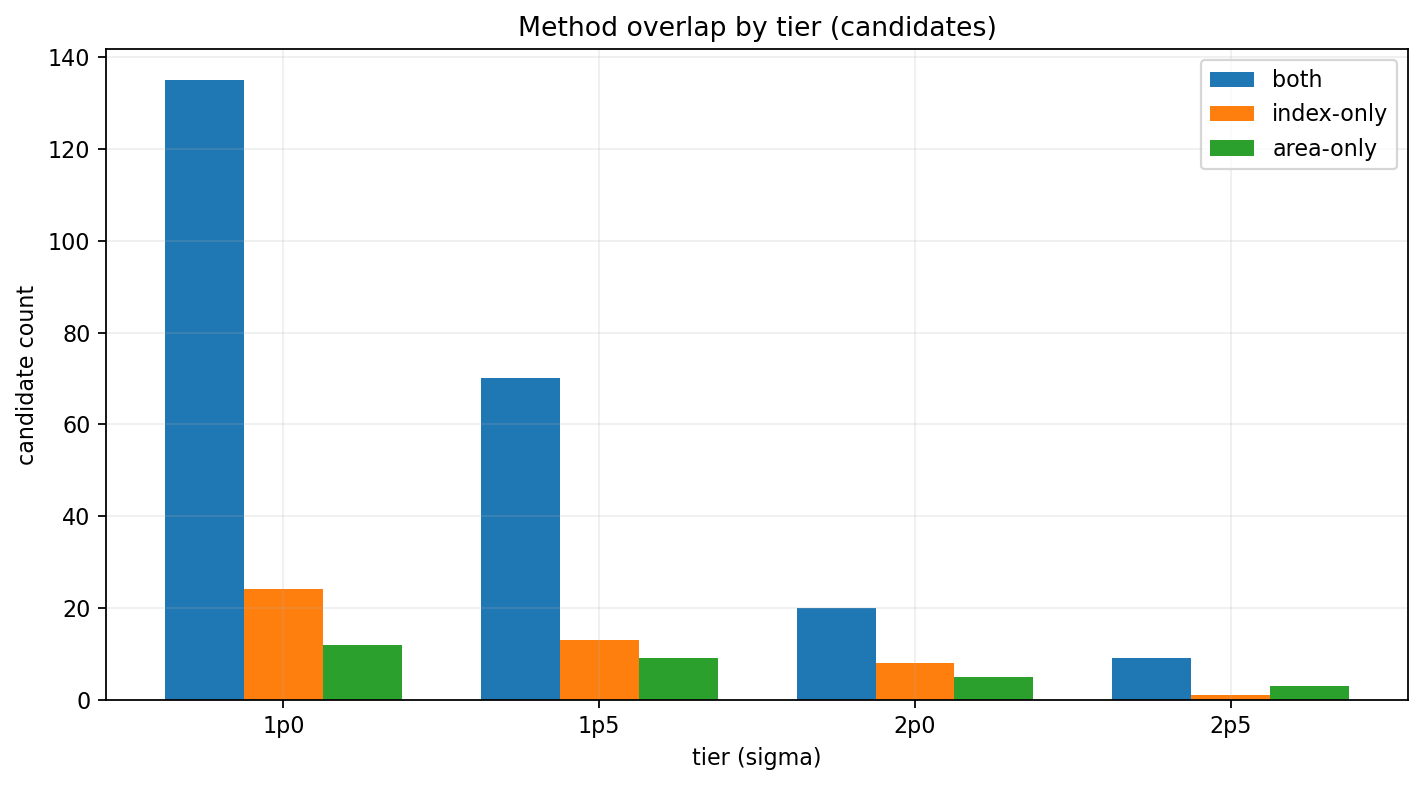

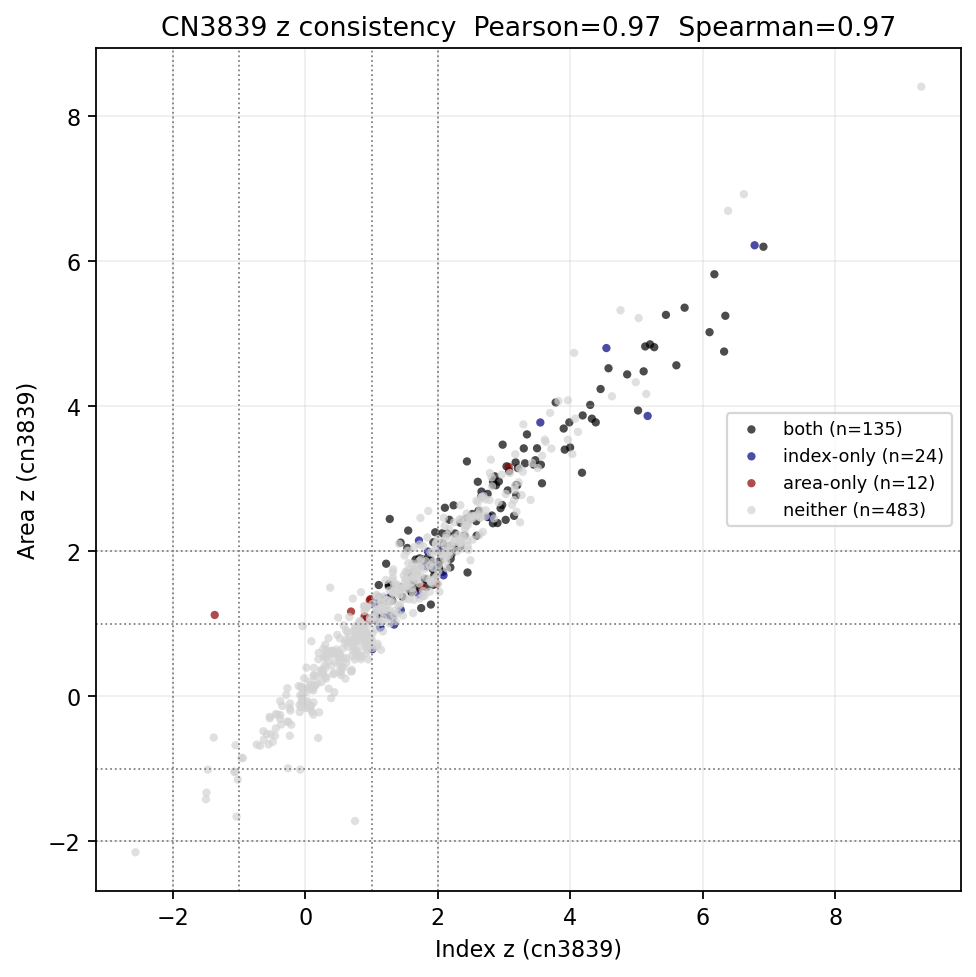

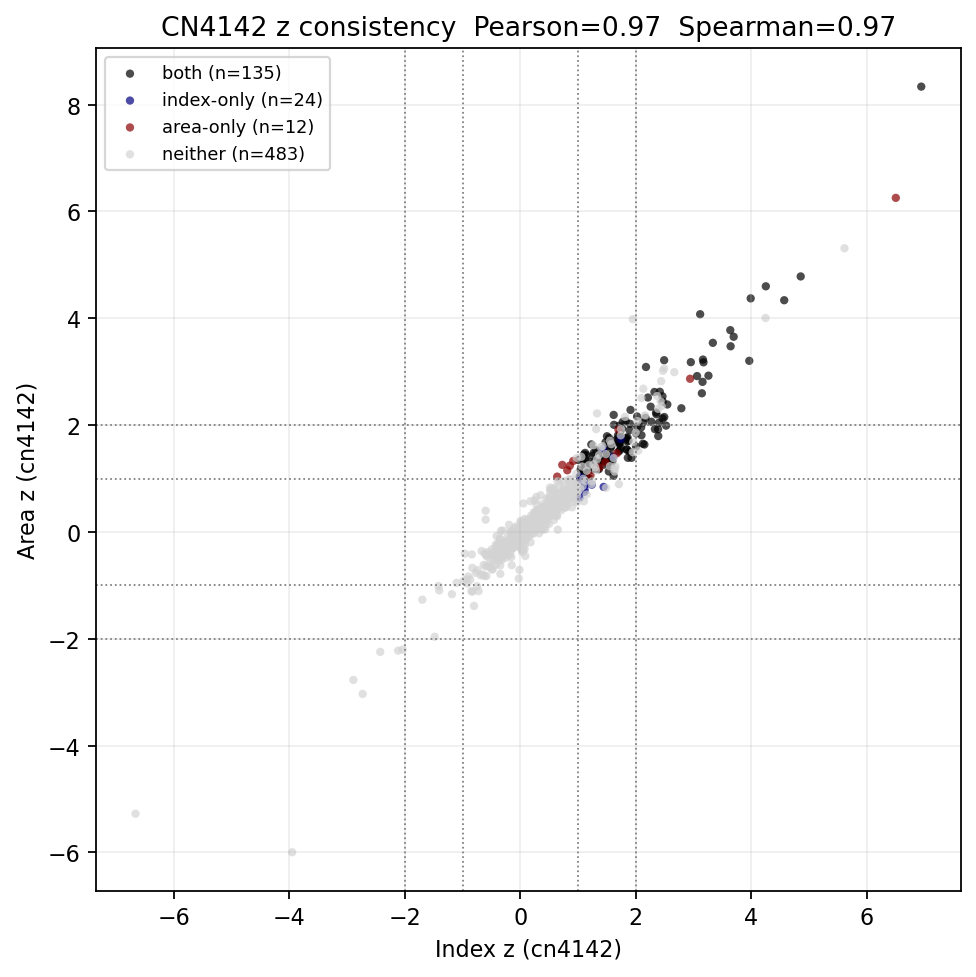

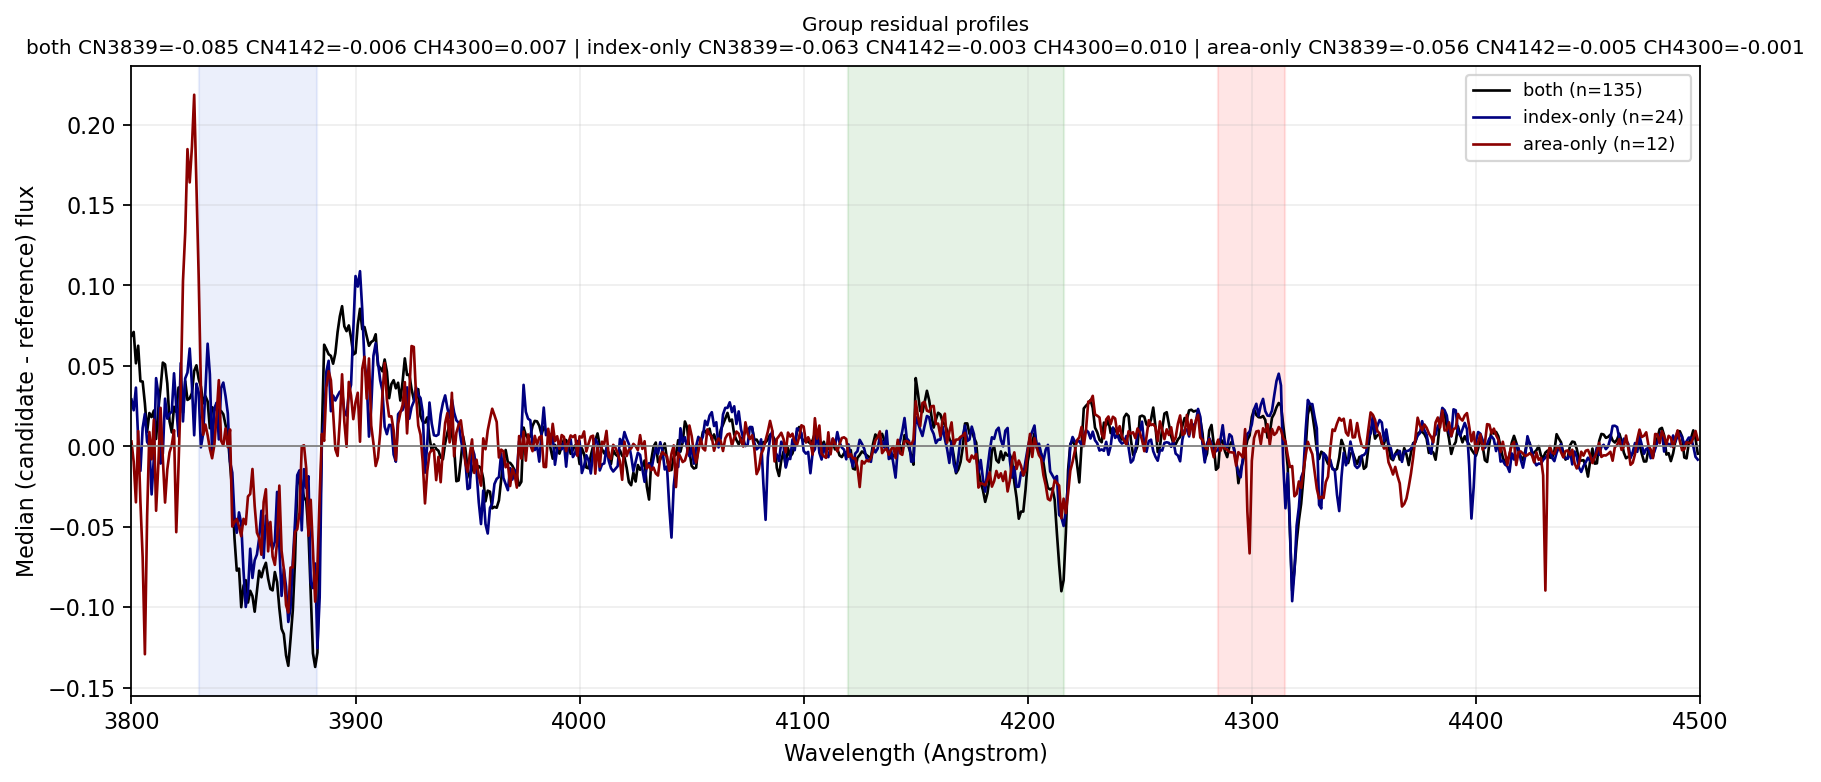

--- both ---


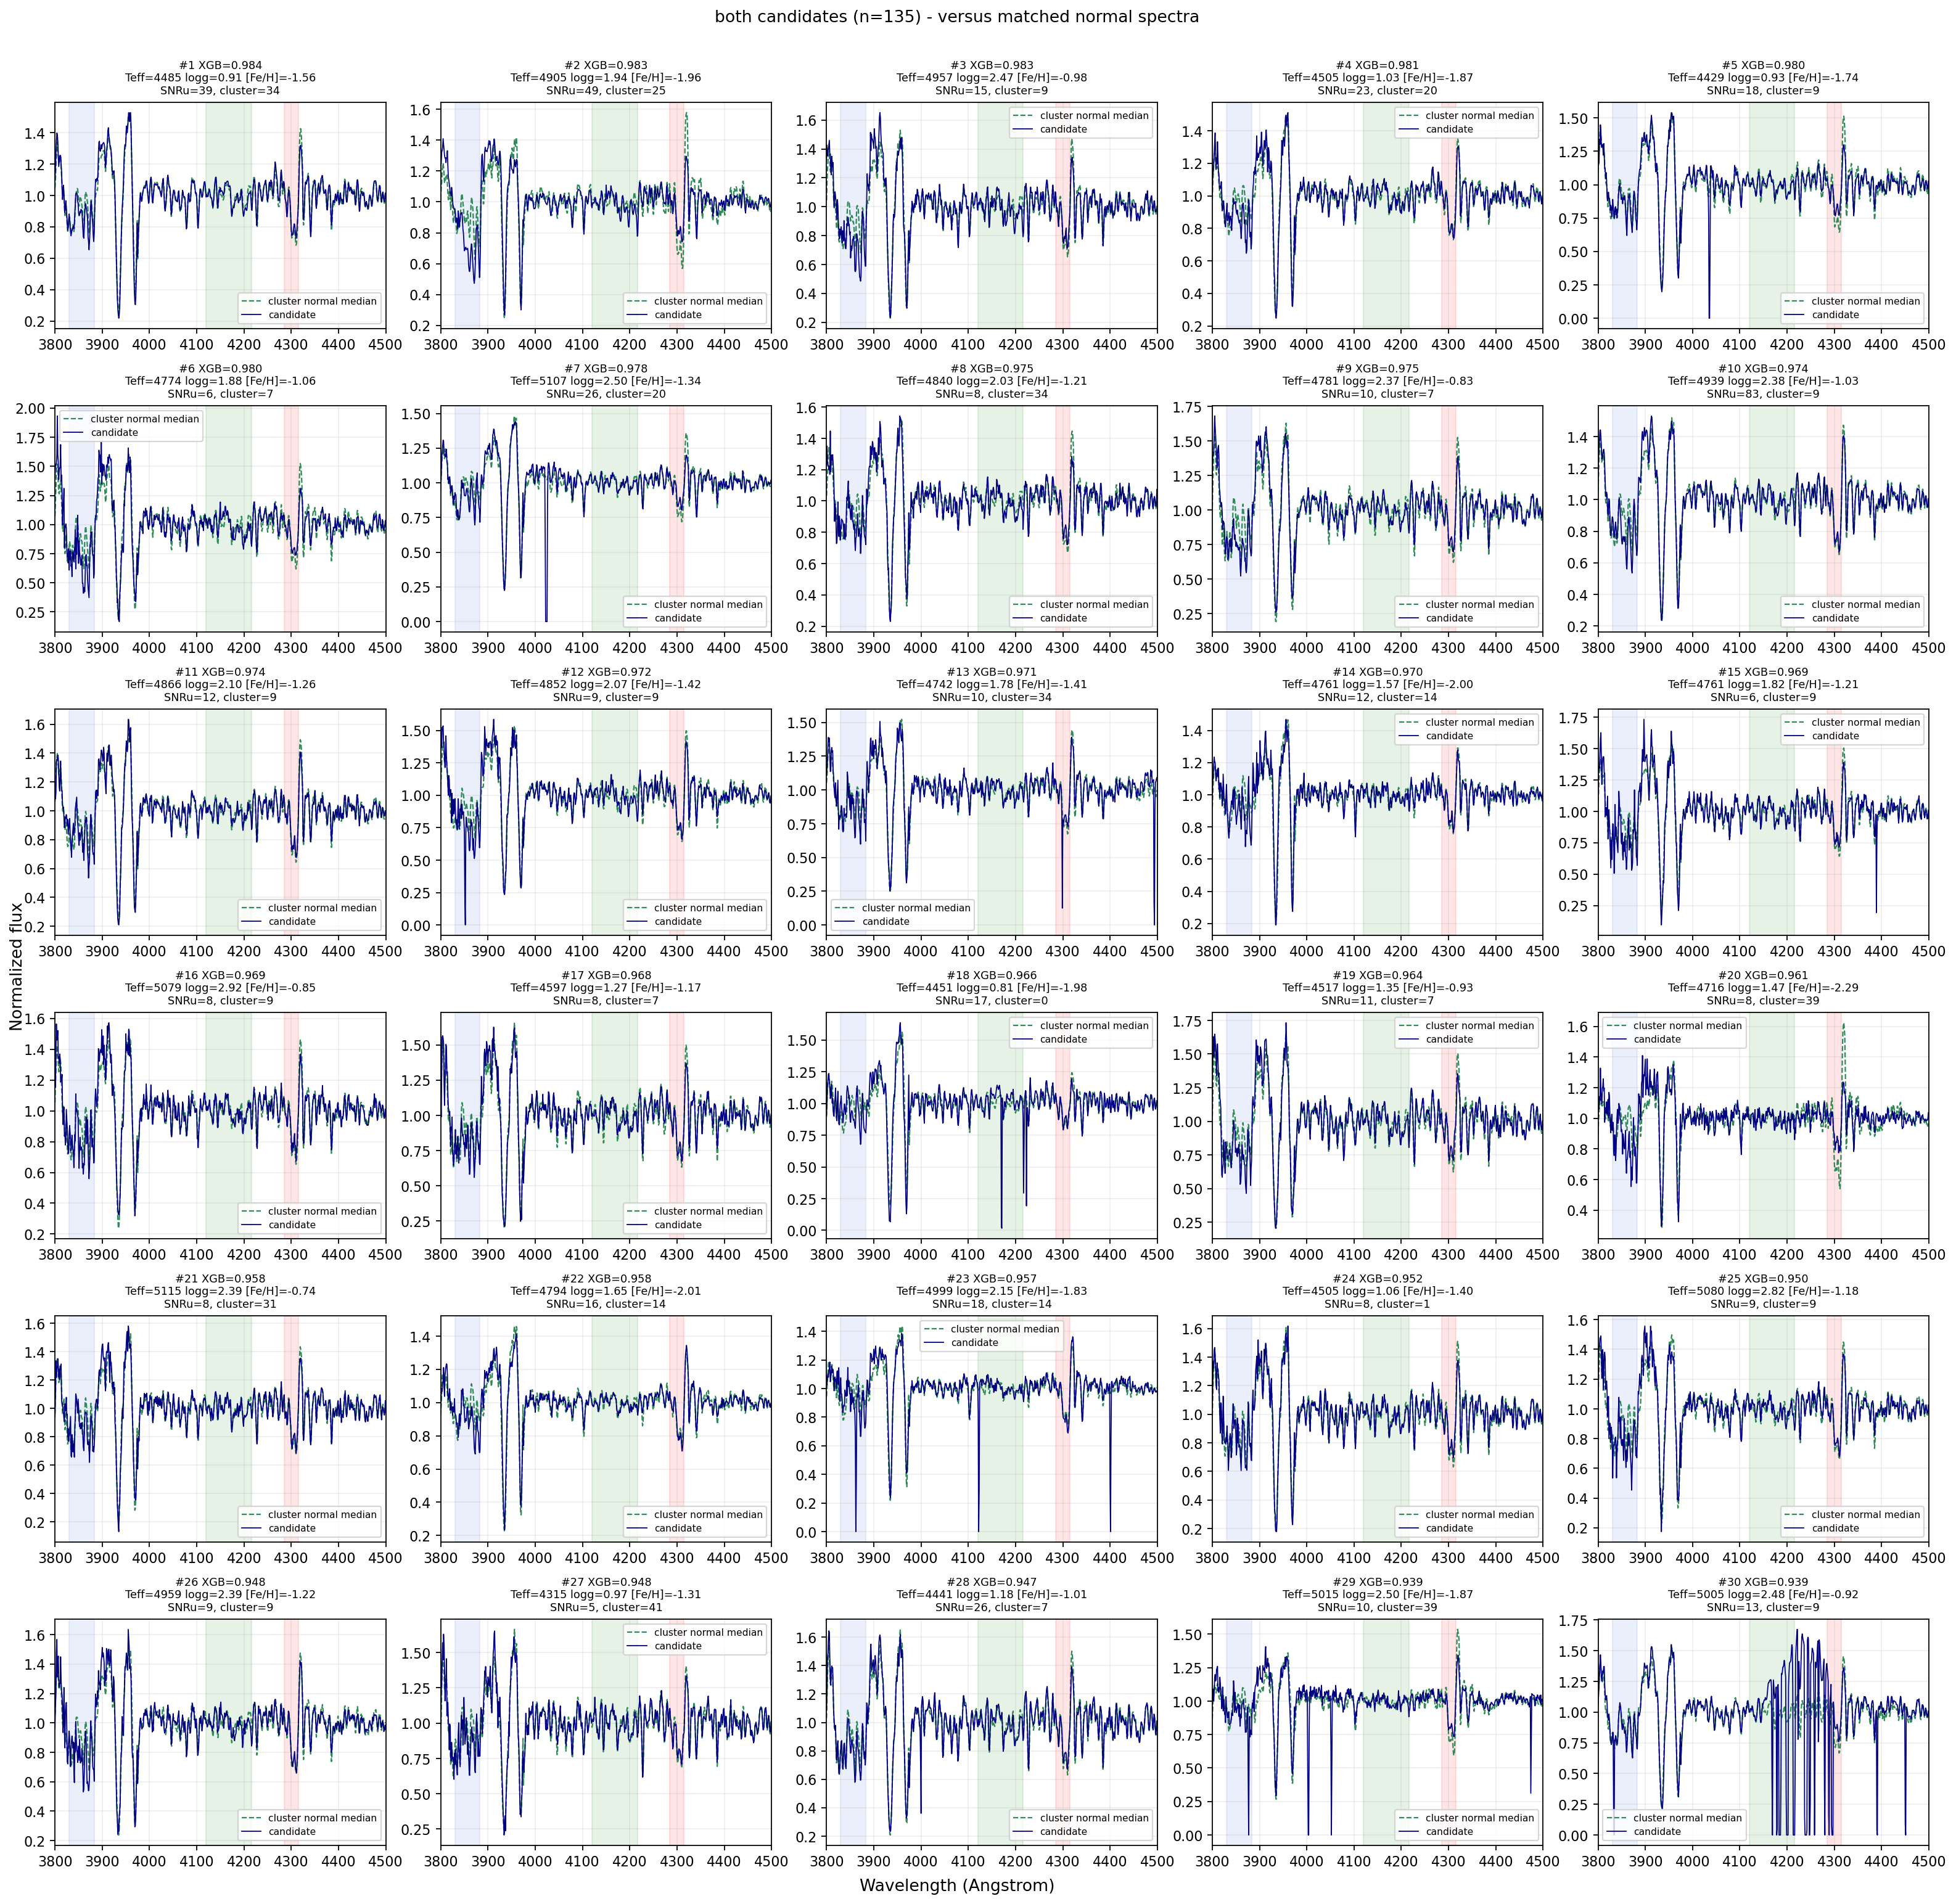

--- index-only ---


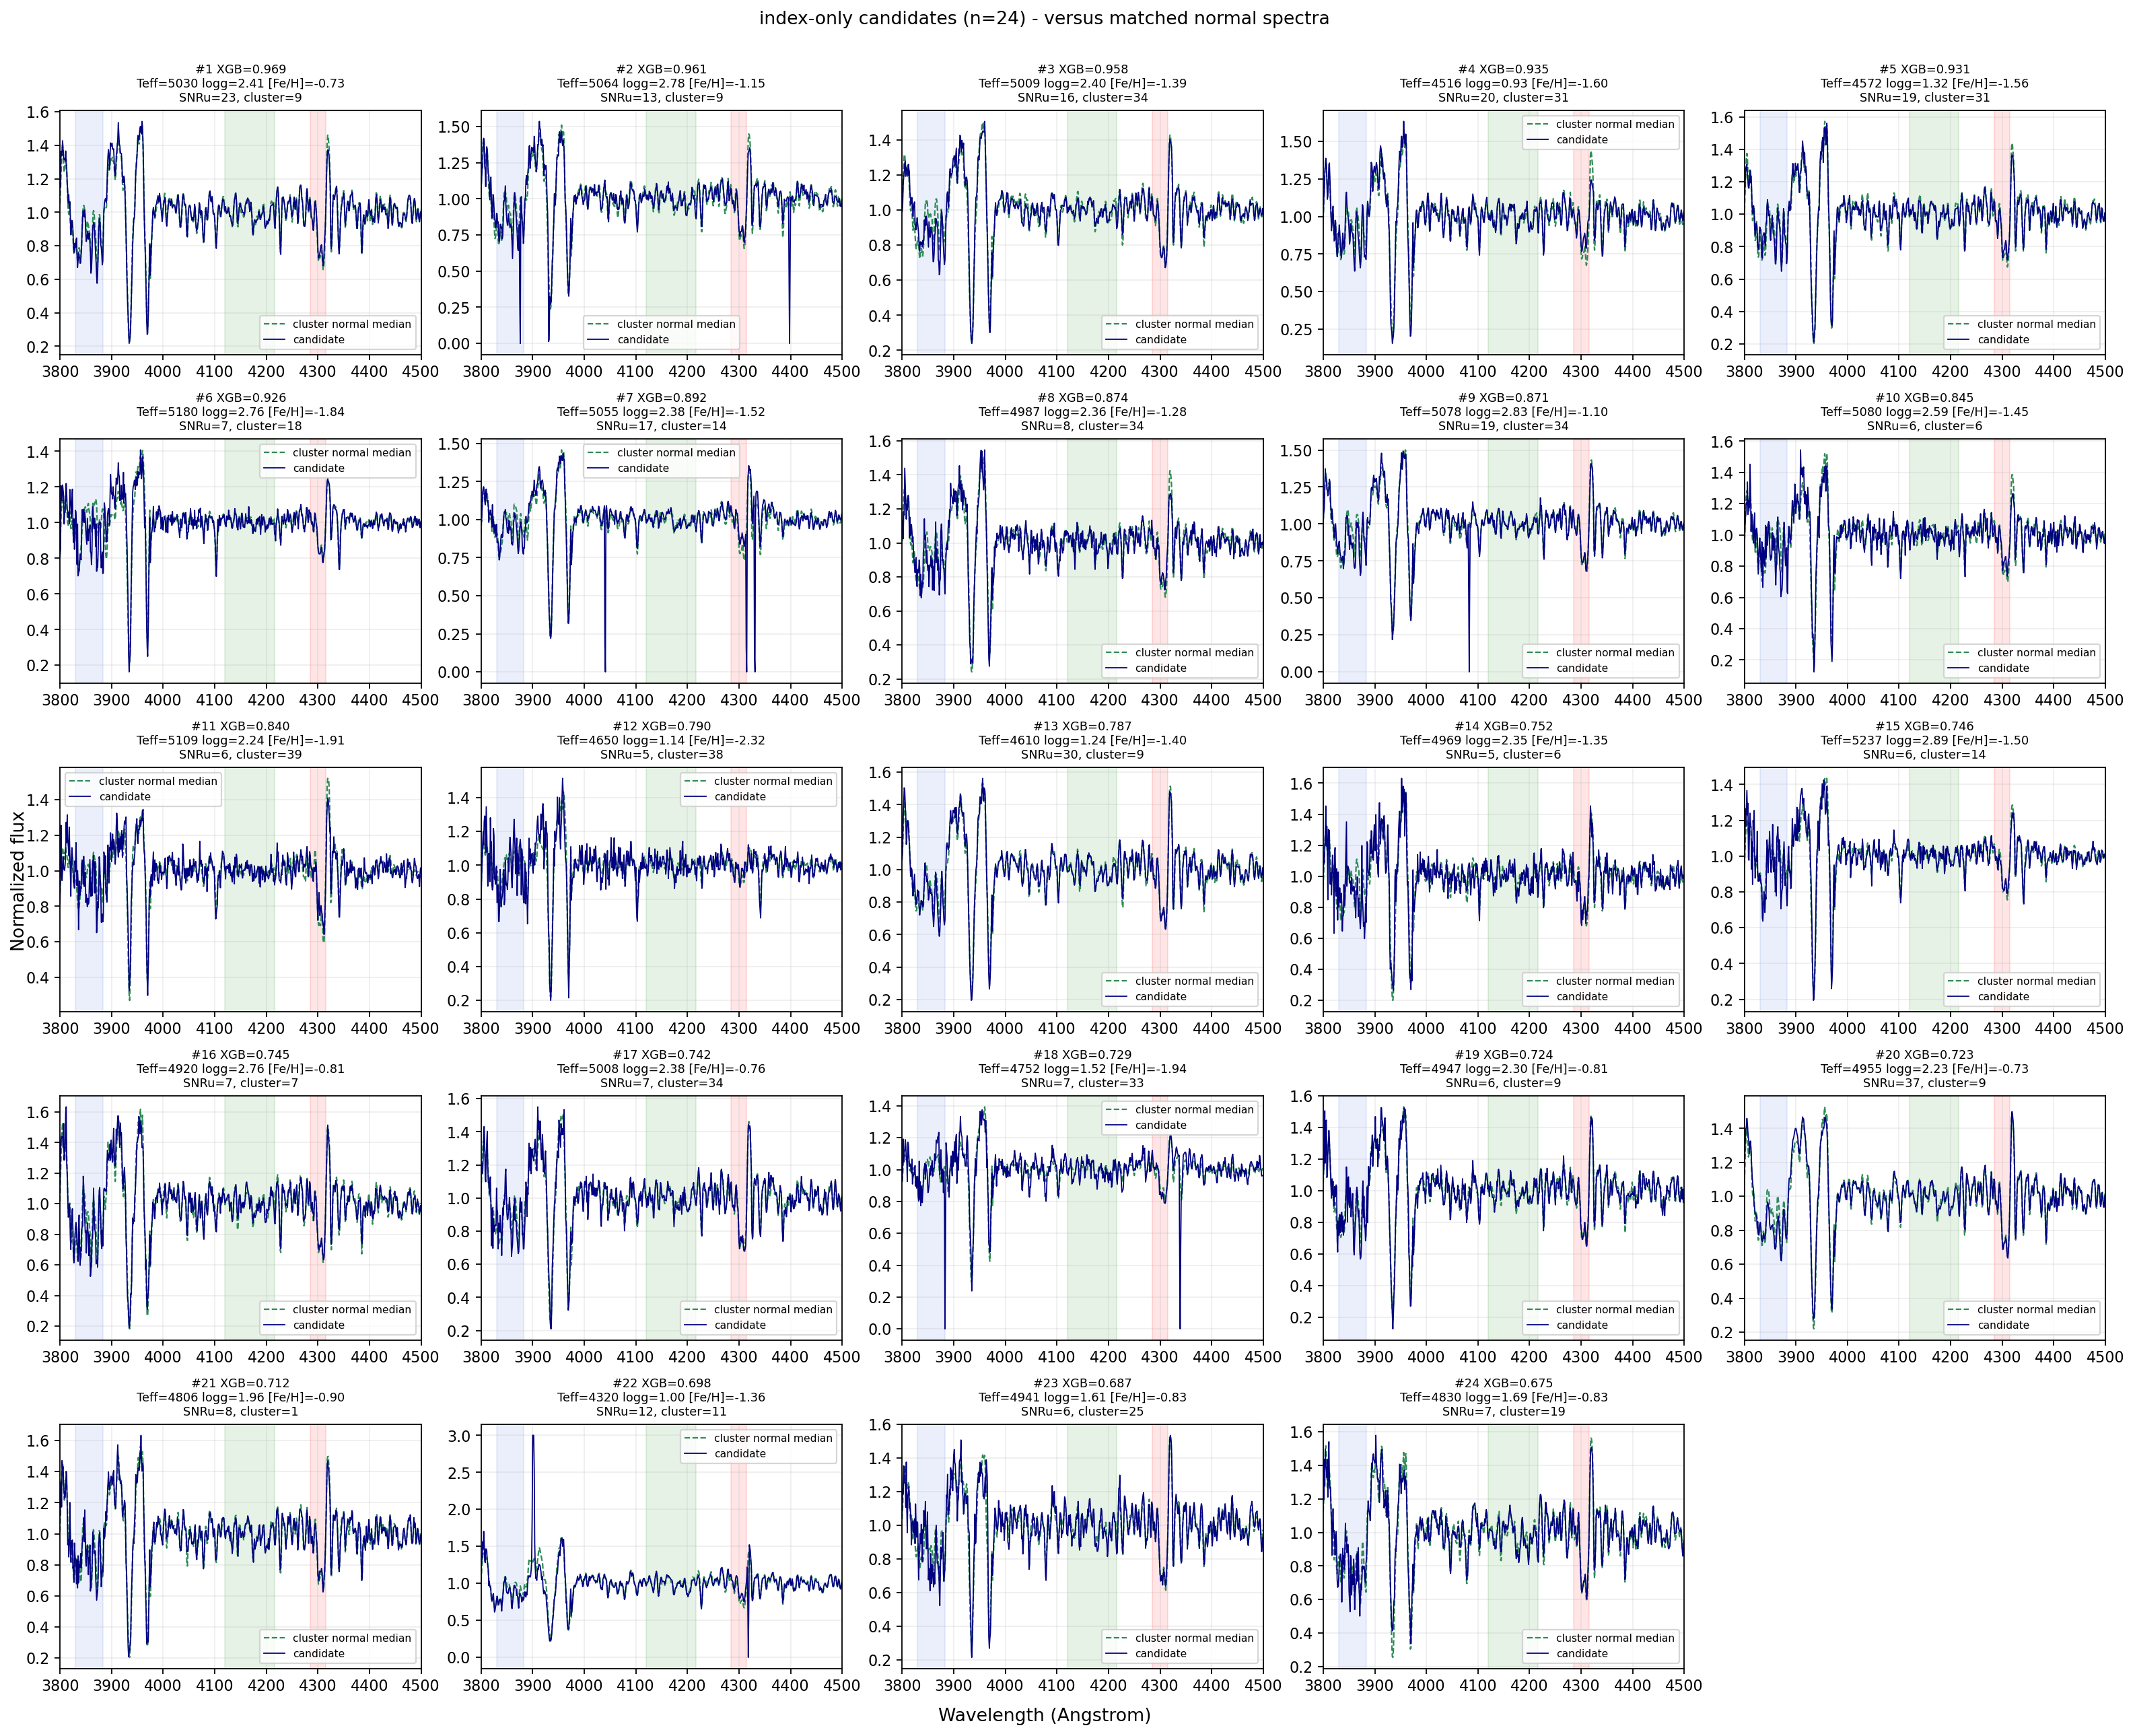

--- area-only ---


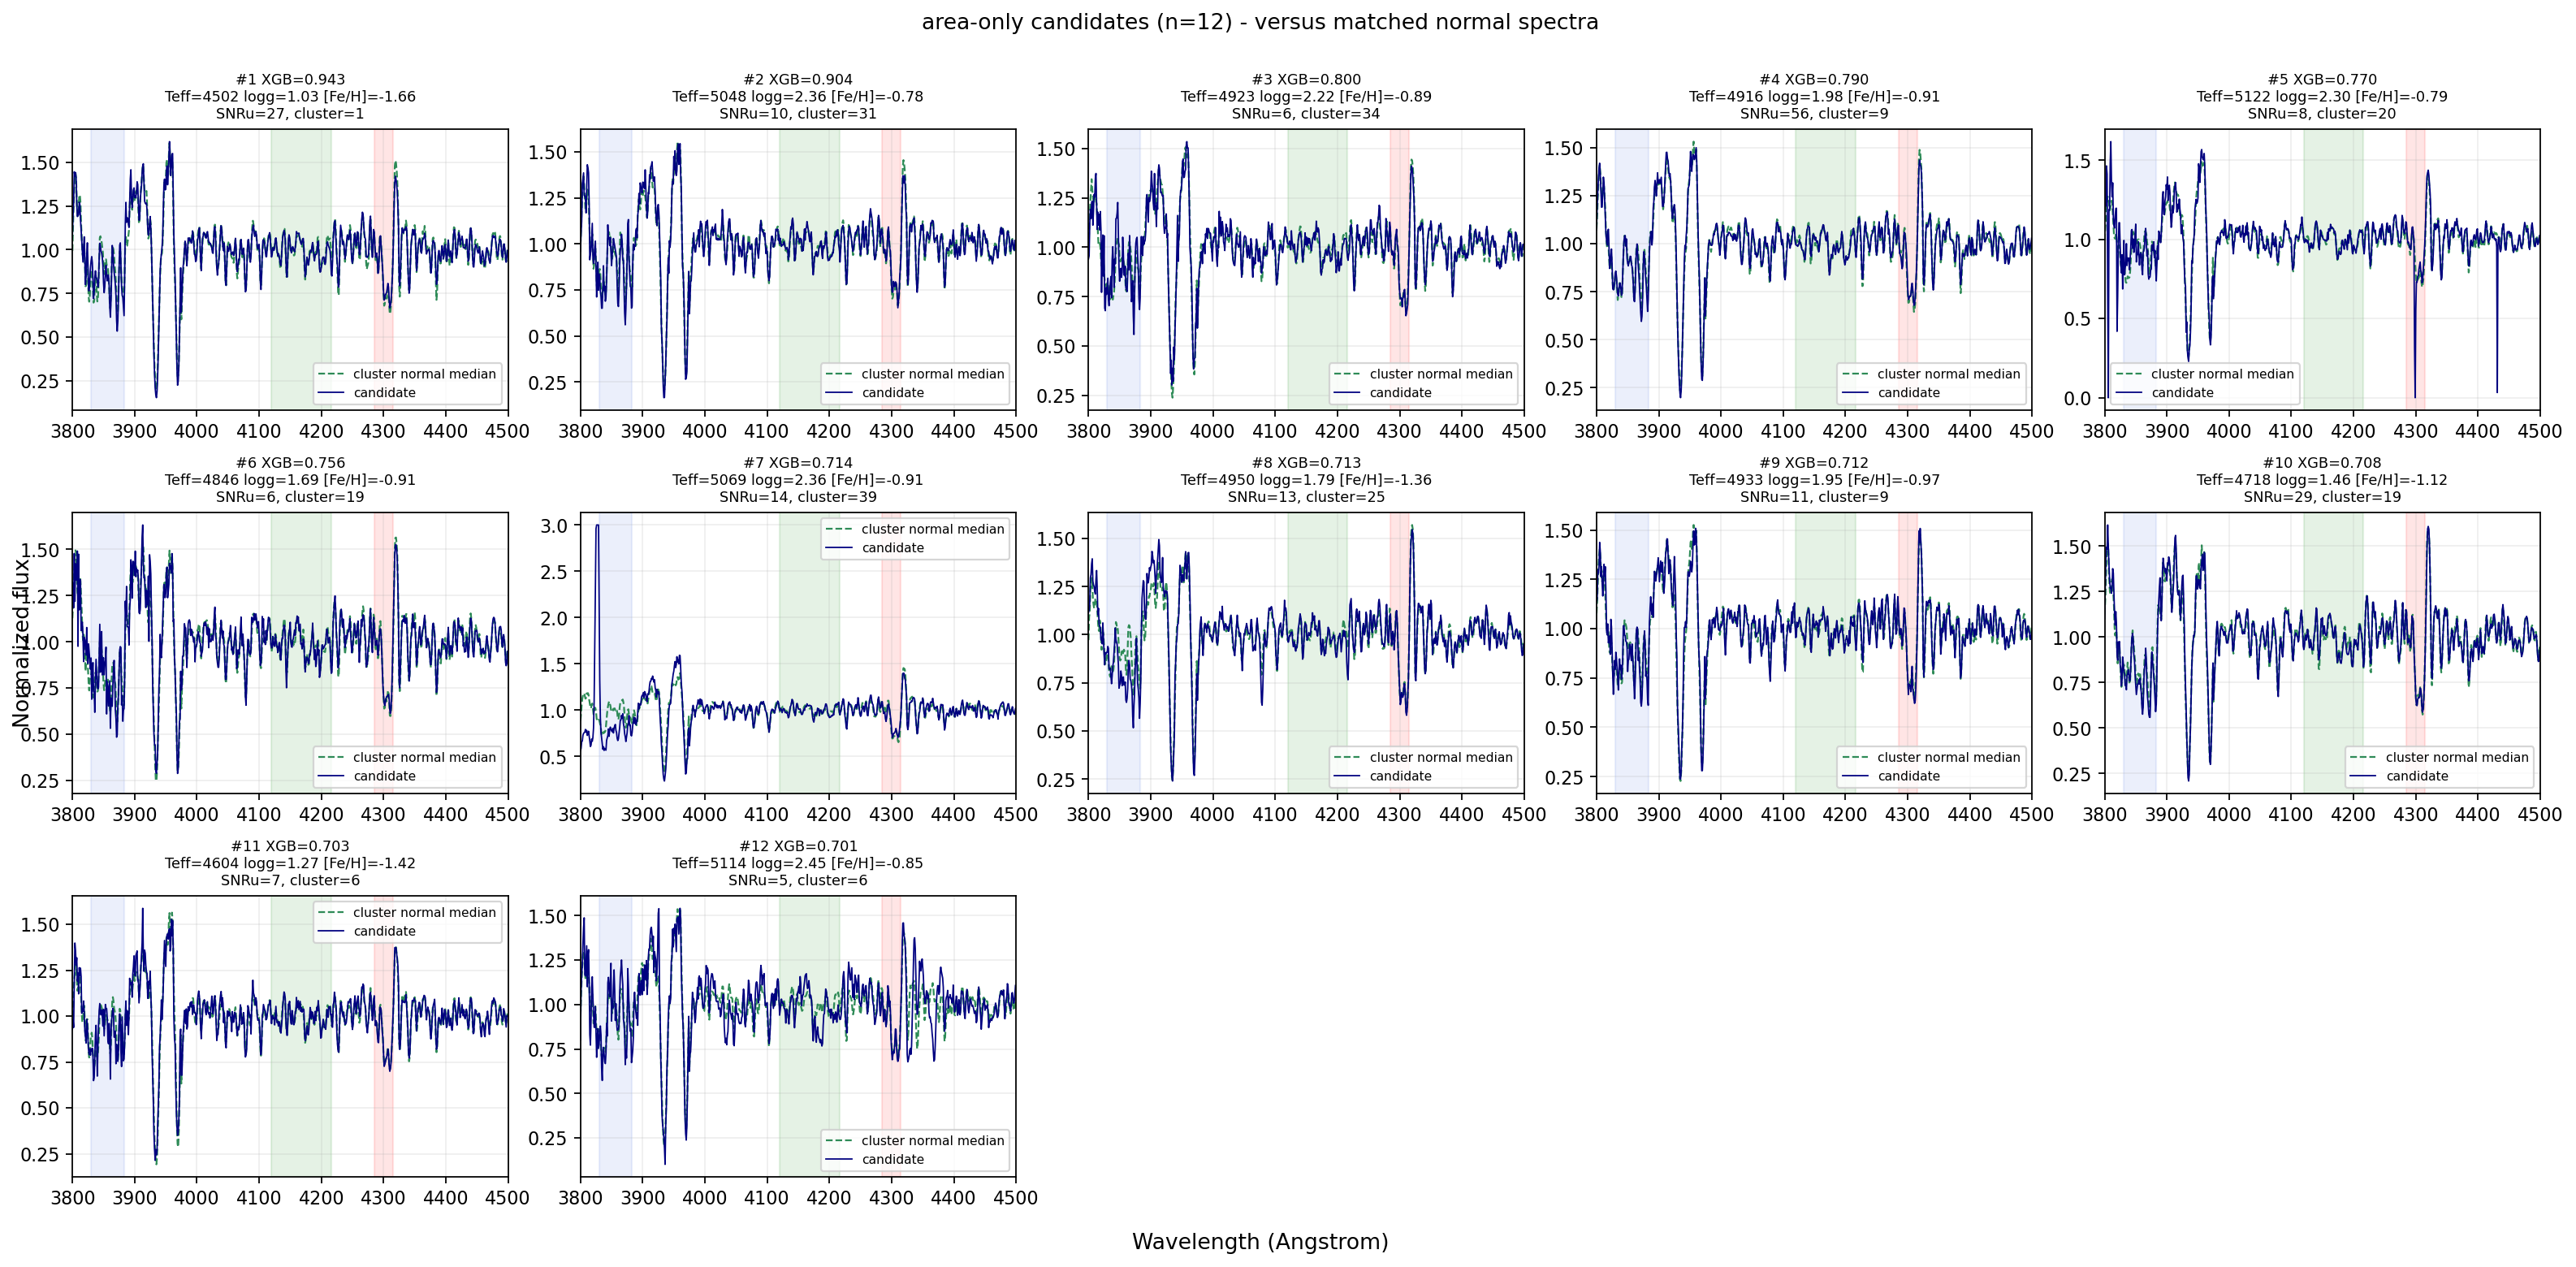

In [8]:
cd = cx.RESULTS_CROSSCHECK_DIR
display(Image(filename=str(cd / 'overlap_by_tier.png'), width=900))
for band in ('cn3839', 'cn4142'):
    display(Image(filename=str(cd / f'z_consistency_{band}.png'), width=620))
display(Image(filename=str(cd / 'group_residual_profiles.png'), width=1000))
for grp, fname in (('both', 'shared_top30.png'), ('index-only', 'index_only_top30.png'), ('area-only', 'area_only_top30.png')):
    print('---', grp, '---')
    display(Image(filename=str(cd / fname), width=1000))

In [9]:
summary = json.loads((cd / 'crosscheck_summary.json').read_text(encoding='utf-8'))
print(json.dumps({
    'candidate_universe': summary['candidate_universe'],
    'known_universe': summary['known_universe'],
    'z_consistency': summary['z_consistency'],
    'group_residual_band_means_1p0': summary['group_residual_band_means_1p0'],
    'reproducibility': summary['reproducibility'],
}, ensure_ascii=False, indent=2))

{
  "candidate_universe": 654,
  "known_universe": 91,
  "z_consistency": {
    "cn3839": {
      "pearson": 0.9718052799708583,
      "spearman": 0.971646471697747
    },
    "cn4142": {
      "pearson": 0.9717223410347744,
      "spearman": 0.9731183855493247
    }
  },
  "group_residual_band_means_1p0": [
    {
      "group": "both",
      "n": 135,
      "cn3839": -0.0850747684,
      "cn4142": -0.0060166185,
      "ch4300": 0.0069183726
    },
    {
      "group": "index-only",
      "n": 24,
      "cn3839": -0.0631721911,
      "cn4142": -0.0028535367,
      "ch4300": 0.0102527023
    },
    {
      "group": "area-only",
      "n": 12,
      "cn3839": -0.0561447475,
      "cn4142": -0.005173272,
      "ch4300": -0.0009485773
    }
  ],
  "reproducibility": "rebuilt 1sigma uid sets match frozen exports (checked in load_method_tables)"
}
